In [2]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path
import csv
import json
import subprocess
import re
from pathlib import Path

# Display settings: do not abbreviate DataFrame output
pd.set_option("display.max_rows", None)        # show all rows
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", None)           # don't wrap to fit console width
pd.set_option("display.max_colwidth", None)    # don't truncate column contents


In [14]:
BASE_DIR = Path("responses/asia")
SUMMARY_CSV = BASE_DIR / "eval_summary.csv"

df = pd.read_csv(SUMMARY_CSV)

In [17]:
sachs_df = pd.read_csv("/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary.csv")

In [22]:
import pandas as pd

df = sachs_df.copy()
df = df[df["evaluated"] == 1].copy()

df["method"] = df["prompt_style"].map({
    "summary": "LLM-summary",
    "summary_joint": "LLM-summary_joint",
    "matrix": "LLM-matrix",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# optional: drop matrix context-fail rows
df = df[~((df["prompt_style"] == "matrix") & (df["context_exceeded_any"] == 1))].copy()

metric = "avg"  # or "consensus"
score_col = f"{metric}_f1"
err_col   = f"{metric}_shd"

# aggregate to one value per (method, anonymize, obs_n, int_n)
agg = (df.groupby(["method","anonymize","obs_n","int_n"], as_index=False)
         .agg(f1=(score_col,"mean"), shd=(err_col,"mean")))

# cells where summary_joint exists
joint_cells = agg.loc[agg["method"] == "LLM-summary_joint", ["anonymize","obs_n","int_n"]].drop_duplicates()

# keep only those cells for all methods
agg2 = agg.merge(joint_cells, on=["anonymize","obs_n","int_n"], how="inner")

macro = (agg2.groupby(["method","anonymize"], as_index=False)
           .agg(mean_f1=("f1","mean"), mean_shd=("shd","mean"), cells=("f1","count"))
           .sort_values(["anonymize","mean_shd"]))

macro


,method,anonymize,mean_f1,mean_shd,cells
0,LLM-matrix,0,0.432006,16.000000,5
1,LLM-summary,0,0.471606,16.200000,7
2,LLM-summary_joint,0,0.406712,24.508642,9


In [2]:
from pathlib import Path
import pandas as pd

base = Path("/home/yuen_chen/ENCO/experiments/responses/sachs")
rows = []

for anon in [0, 1]:
    suffix = "_anon" if anon == 1 else ""
    for obs in [100, 200, 1000, 5000, 8000]:
        for inter in [0,  50, 100, 200, 500]:
            csv_name = f"responses_obs{obs}_int{inter}_shuf1_p5{suffix}_summary_joint_gpt-5-mini.csv"
            csv_path = base / csv_name
            summary_path = csv_path.with_suffix(csv_path.suffix + ".summary.json")
            rows.append({
                "anonymize": anon,
                "obs_n": obs,
                "int_n": inter,
                "csv_exists": csv_path.exists(),
                "summary_exists": summary_path.exists(),
                "csv": str(csv_path),
            })

status_df = pd.DataFrame(rows).sort_values(["anonymize", "obs_n", "int_n"]).reset_index(drop=True)
status_df


,anonymize,obs_n,int_n,csv_exists,summary_exists,csv
0,0,100,0,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
1,0,100,50,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
2,0,100,100,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
3,0,100,200,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
4,0,100,500,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
5,0,200,0,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
6,0,200,50,True,True,/home/yuen_chen/ENCO/experiments/responses/sac...
7,0,200,100,False,False,/home/yuen_chen/ENCO/experiments/responses/sac...
8,0,200,200,False,False,/home/yuen_chen/ENCO/experiments/responses/sac...
9,0,200,500,False,False,/home/yuen_chen/ENCO/experiments/responses/sac...


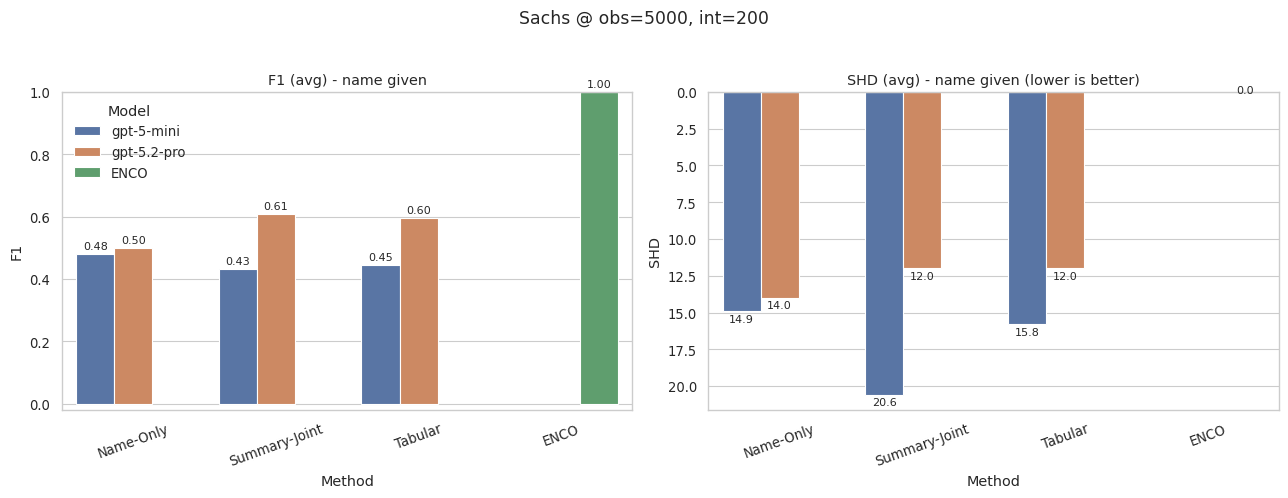

Saved: /home/yuen_chen/ENCO/experiments/out/figures_pubready/sachs_obs5000_int200_name_given_avg_with_name_only.pdf


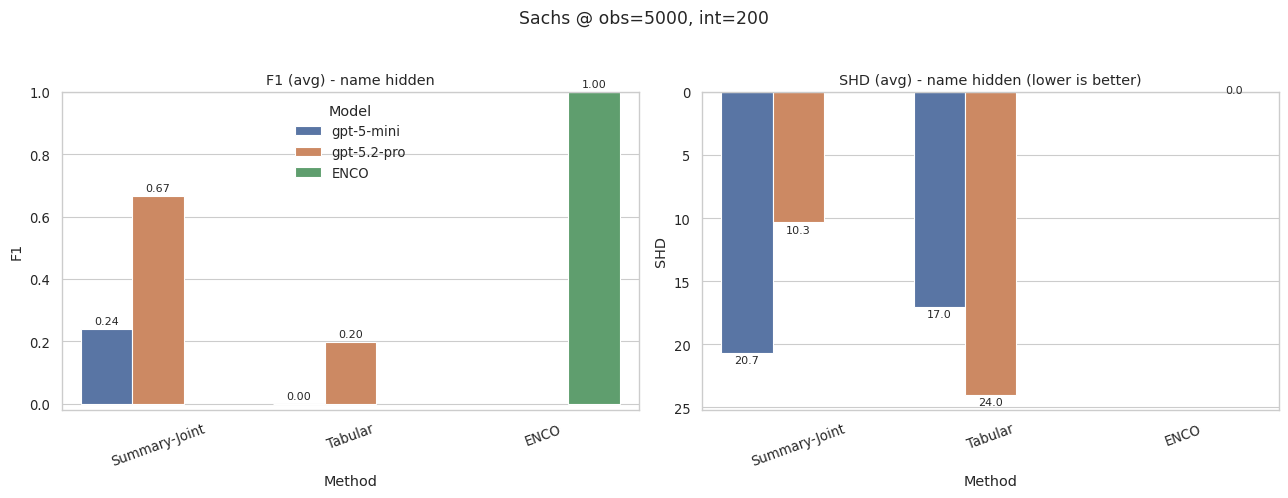

Saved: /home/yuen_chen/ENCO/experiments/out/figures_pubready/sachs_obs5000_int200_name_hidden_avg_with_name_only.pdf


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv = "/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary.csv"
obs_target, int_target = 5000, 200
metric = "avg"  # fixed as requested
models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507"]
include_enco = True
out_dir = Path("/home/yuen_chen/ENCO/experiments/out/figures_pubready")
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()

# map methods
df["method"] = df["prompt_style"].map({
    # "summary": "Summary",
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# keep selected models (+ ENCO)
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

# split: main configs at obs/int, plus names-only (obs/int independent)
main = df[df["method"].isin([ "Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]

name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])

# one plot for non-anon, one for anon
for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    # omit Name-Only for name-hidden panel
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    # ENCO shown in both plots; LLM methods filtered by anonymize
    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    # aggregate duplicates
    agg = (sub.groupby(["model", "method"], as_index=False)
             .agg(f1=(f1_col, "mean"), shd=(shd_col, "mean")))

    # ENCO bar uses label "ENCO"
    agg["model_group"] = agg["model"]
    agg.loc[agg["method"] == "ENCO", "model_group"] = "ENCO"

    hue_order = models + (["ENCO"] if include_enco else [])
    agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
    panel_method_order = [m for m in method_order if m in agg["method"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.barplot(
        data=agg, x="method", y="f1", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[0]
    )
    axes[0].set_ylim(-0.02, 1.0)   # instead of (0, 1)
    axes[0].set_title(f"F1 ({metric}) - {anon_label.replace('_',' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    # axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Model", frameon=False, loc="best")



    sns.barplot(
        data=agg, x="method", y="shd", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[1]
    )
    axes[1].set_title(f"SHD ({metric}) - {anon_label.replace('_',' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    axes[1].tick_params(axis="x", rotation=20)
    # axes[1].set_ylim(-0.02, 25.0)
    axes[1].invert_yaxis()   # <-- key line
    axes[1].legend_.remove()

    # F1 labels
    for c in axes[0].containers:
        vals = c.datavalues
        labels = [f"{v:.2f}" if pd.notna(v) else "" for v in vals]
        axes[0].bar_label(c, labels=labels, padding=2, fontsize=8)

    # SHD labels (below bars; axis inverted)
    for c in axes[1].containers:
        vals = c.datavalues
        labels = [f"{v:.1f}" if pd.notna(v) else "" for v in vals]
        axes[1].bar_label(c, labels=labels, padding=2, fontsize=8)

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_with_name_only.pdf"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


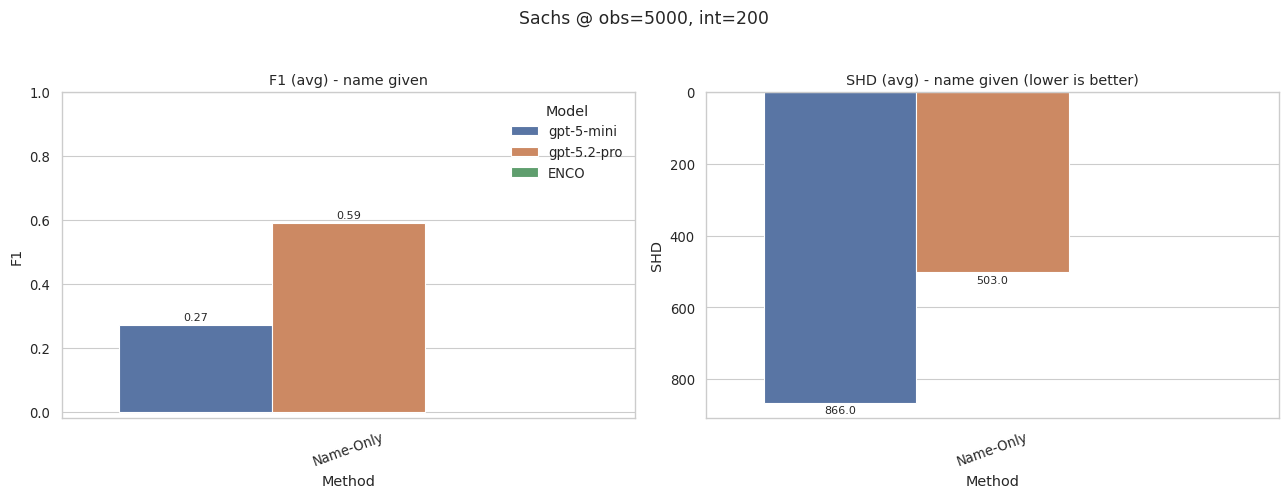

Saved: /home/yuen_chen/ENCO/experiments/out/figures_pubready/sachs_obs5000_int200_name_given_avg_with_name_only.pdf


/tmp/ipykernel_590225/3686181835.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(title="Model", frameon=False, loc="best")


AttributeError: 'NoneType' object has no attribute 'remove'

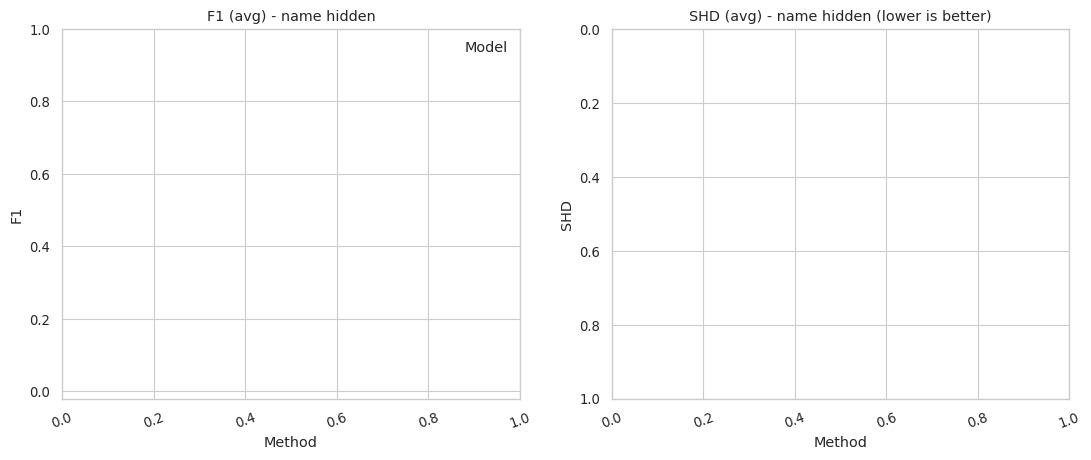

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv = "/home/yuen_chen/ENCO/experiments/out/experiment1/diabetes_summary.csv"
obs_target, int_target = 5000, 200
metric = "avg"  # fixed as requested
models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507"]
include_enco = True
out_dir = Path("/home/yuen_chen/ENCO/experiments/out/figures_pubready")
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()

# map methods
df["method"] = df["prompt_style"].map({
    # "summary": "Summary",
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# keep selected models (+ ENCO)
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

# split: main configs at obs/int, plus names-only (obs/int independent)
main = df[df["method"].isin([ "Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]

name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])

# one plot for non-anon, one for anon
for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    # omit Name-Only for name-hidden panel
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    # ENCO shown in both plots; LLM methods filtered by anonymize
    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    # aggregate duplicates
    agg = (sub.groupby(["model", "method"], as_index=False)
             .agg(f1=(f1_col, "mean"), shd=(shd_col, "mean")))

    # ENCO bar uses label "ENCO"
    agg["model_group"] = agg["model"]
    agg.loc[agg["method"] == "ENCO", "model_group"] = "ENCO"

    hue_order = models + (["ENCO"] if include_enco else [])
    agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
    panel_method_order = [m for m in method_order if m in agg["method"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.barplot(
        data=agg, x="method", y="f1", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[0]
    )
    axes[0].set_ylim(-0.02, 1.0)   # instead of (0, 1)
    axes[0].set_title(f"F1 ({metric}) - {anon_label.replace('_',' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    # axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Model", frameon=False, loc="best")



    sns.barplot(
        data=agg, x="method", y="shd", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[1]
    )
    axes[1].set_title(f"SHD ({metric}) - {anon_label.replace('_',' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    axes[1].tick_params(axis="x", rotation=20)
    # axes[1].set_ylim(-0.02, 25.0)
    axes[1].invert_yaxis()   # <-- key line
    axes[1].legend_.remove()

    # F1 labels
    for c in axes[0].containers:
        vals = c.datavalues
        labels = [f"{v:.2f}" if pd.notna(v) else "" for v in vals]
        axes[0].bar_label(c, labels=labels, padding=2, fontsize=8)

    # SHD labels (below bars; axis inverted)
    for c in axes[1].containers:
        vals = c.datavalues
        labels = [f"{v:.1f}" if pd.notna(v) else "" for v in vals]
        axes[1].bar_label(c, labels=labels, padding=2, fontsize=8)

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_with_name_only.pdf"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)
